In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import os
import pygtc

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
fid50 = jsm_ancillary.load_massspec("../../data/Nparticle/N50/", "artificial", 0)

satgen50 = fid50[fid50["logMvir"] > 12.5]
satgen50 = satgen50.sort_values("logMvir")

In [5]:
fid500 = jsm_ancillary.load_massspec("../../data/Nparticle/N500/", "artificial", 0)

satgen500 = fid500[fid500["logMvir"] > 12.5]
satgen500 = satgen500.sort_values("logMvir")

In [6]:
fid1000 = jsm_ancillary.load_massspec("../../data/Nparticle/N1000/", "artificial", 0)

satgen1000 = fid1000[fid1000["logMvir"] > 12.5]
satgen1000 = satgen1000.sort_values("logMvir")

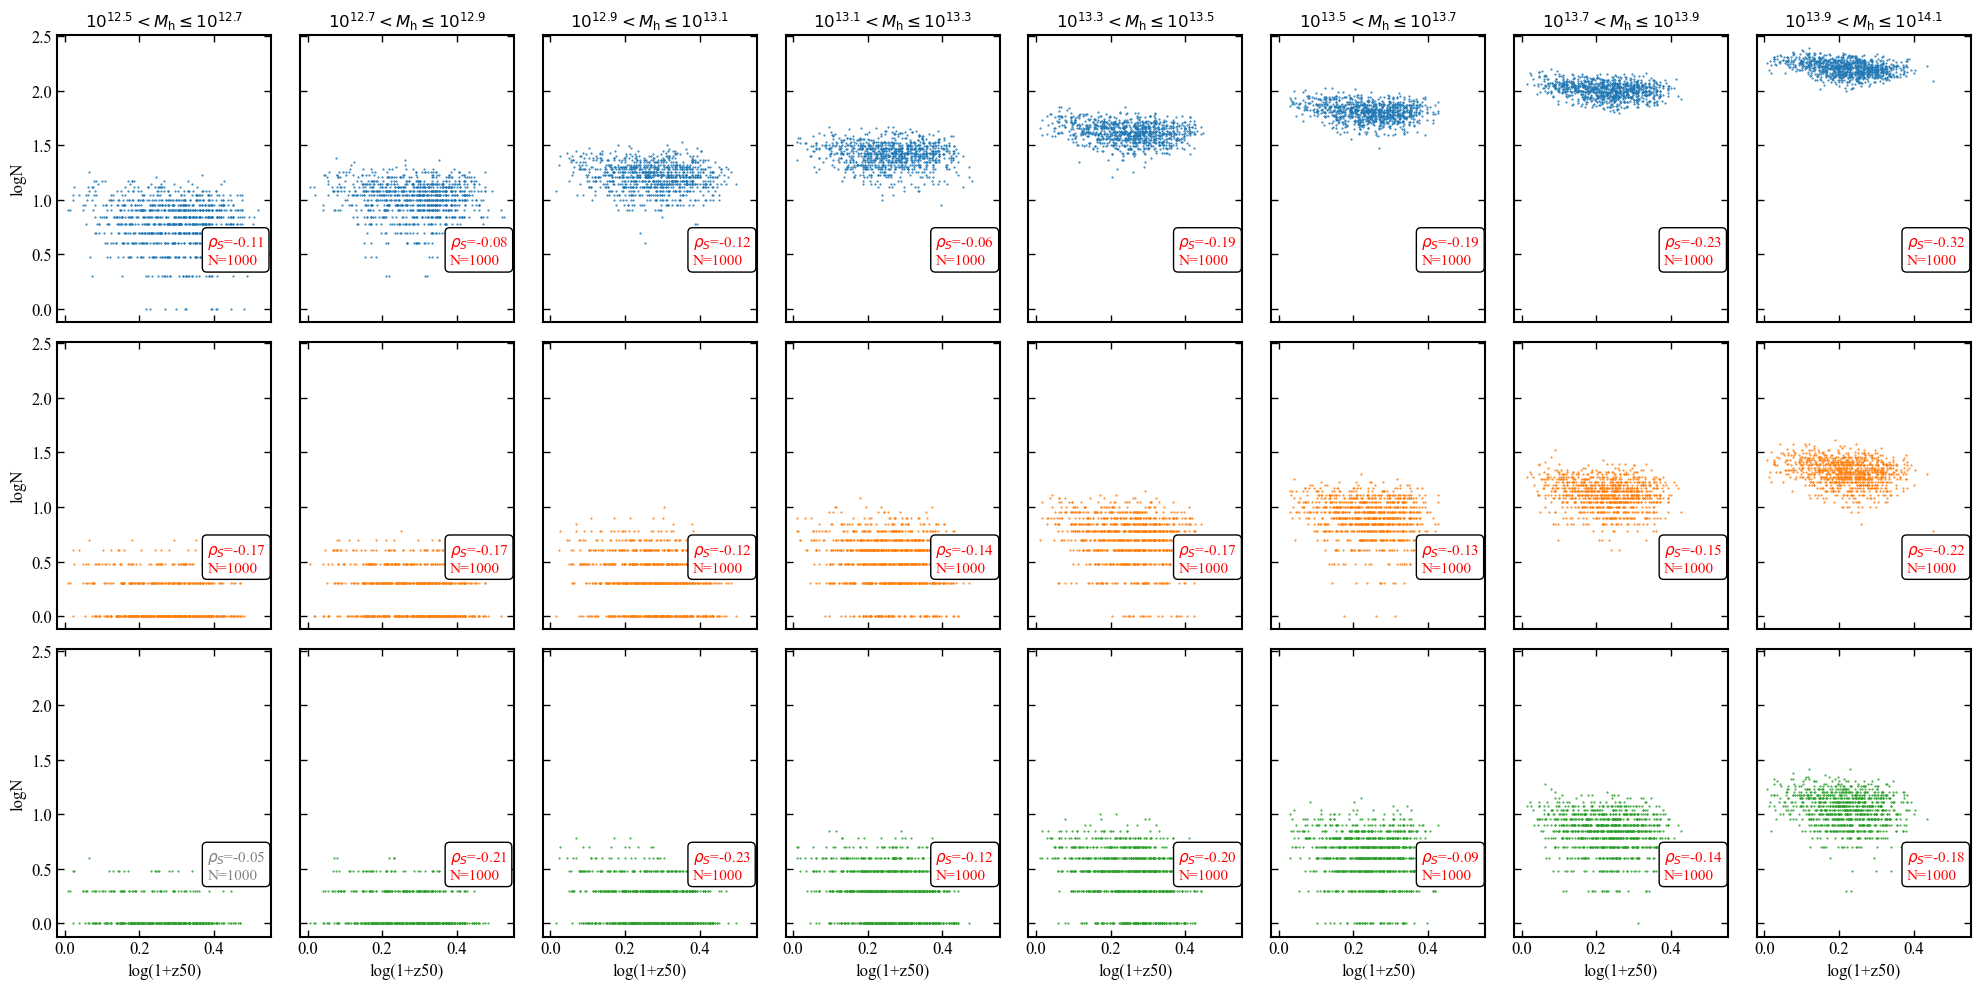

In [7]:
rho_matz, N_hosts = jsm_simload.mass_binned_rho([satgen50, satgen500, satgen1000], xkey="log1pz50", ykey="logNsub", xlabel="log(1+z50)", ylabel="logN", make_plot=True)

rho_matc, _ = jsm_simload.mass_binned_rho([satgen50, satgen500, satgen1000], xkey="logc", ykey="logNsub", xlabel="log c", ylabel="logN", make_plot=False)

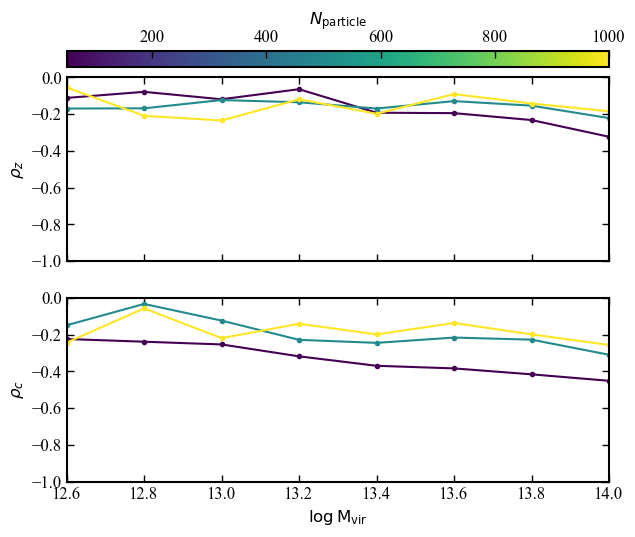

In [8]:
npart = np.array([50, 500, 1000])
logMvir_binned = np.linspace(12.6, 14, 8)

cmap = plt.cm.viridis
norm = Normalize(vmin=npart.min(), vmax=npart.max())

fig, ax = plt.subplots(2, 1, figsize=(double_textwidth, 1.5*single_textwidth), sharex=True, sharey=True)

for k, rho_arr in enumerate(rho_matz):
    ax[0].plot(logMvir_binned, rho_arr, marker=".", color=cmap(norm(npart[k])))

for k, rho_arr in enumerate(rho_matc):
    ax[1].plot(logMvir_binned, rho_arr, marker=".", color=cmap(norm(npart[k])))

ax[0].set_ylabel("$\\rho_z$")
ax[1].set_ylabel("$\\rho_c$")

ax[1].set_ylim(-1, 0)
ax[1].set_xlim(12.6, 14.0)
ax[1].set_xlabel("$\\log \\rm M_{vir}$")

# add horizontal colorbar above top axis
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# get position of top axis and place colorbar above it
pos = ax[0].get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y1 + 0.02, pos.width, 0.03])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("$N_{\\rm particle}$")
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')


plt.show()